# Análise de Dados de Monitoramento da CPU

Este notebook apresenta uma análise exploratória dos dados obtidos durante o monitoramento de um processador ao longo do tempo.

O principal objetivo é investigar o comportamento térmico dos diferentes núcleos da CPU, analisando como suas temperaturas variam durante o período de monitoramento e identificando possíveis padrões de comportamento.

Além da análise individual das temperaturas, também serão investigadas as relações entre os diferentes núcleos e entre as demais variáveis disponíveis no conjunto de dados.

Os principais objetivos desta análise são:

* Analisar a evolução das variáveis ao longo do tempo;
* Investigar o comportamento da temperatura de cada núcleo;
* Comparar as temperaturas entre os diferentes núcleos;
* Identificar temperaturas mínimas, médias e máximas;
* Avaliar a variação térmica de cada núcleo;
* Identificar momentos de pico de temperatura;
* Analisar a temperatura média da CPU;
* Identificar qual núcleo apresenta maior temperatura ao longo do tempo;
* Avaliar a correlação entre as variáveis;
* Identificar possíveis padrões e comportamentos anômalos.

A análise será dividida em etapas, começando pela preparação dos dados e avançando para a análise temporal, análise térmica dos núcleos e estudo das correlações.


## 1. Configuração do Ambiente

Nesta etapa são importadas as bibliotecas necessárias para manipulação, tratamento, análise e visualização dos dados.

As bibliotecas utilizadas fornecem recursos para trabalhar com dados tabulares, operações numéricas, representação gráfica e análise estatística.

A configuração inicial do ambiente garante que todas as ferramentas necessárias estejam disponíveis para as etapas seguintes da análise.


In [45]:
import pandas as pd
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Importação dos Dados

O conjunto de dados utilizado nesta análise contém informações coletadas durante o monitoramento do processador.

Cada registro representa uma observação realizada em determinado instante, permitindo analisar a evolução das variáveis durante o período de coleta.

Nesta etapa, o arquivo contendo os dados é carregado e suas primeiras observações são apresentadas para verificar sua estrutura inicial.

Essa verificação permite identificar as variáveis disponíveis, seus respectivos formatos e possíveis informações que necessitem de tratamento antes da análise.


In [46]:
# Configuração da fonte de dados
fonte = "laptop" # desktop, notebook

dataset = pd.read_csv(f"{fonte}-data.CSV", encoding="latin-1" if fonte == "desktop" else "utf-8")
display(dataset.head())

,Date,Time,Memória virtual comprometida [MB],Memória virtual disponível [MB],Carga da memória virtual [%],Memória física utilizada [MB],Memória física disponível [MB],Carga da memória física [%],Utilização do arquivo de paginação [%],Page File Total [MB],...,GPU Wait (avg) [ms],CPU Busy (avg) [ms],CPU Wait (avg) [ms],Animation Error (avg) [ms],Total download [MB],Total upload [MB],Taxa de download atual [KB/s],Taxa de upload atual [KB/s],Total de erros [],Unnamed: 352
0,20.9.2026,11:17:3.319,7904,9187,46.2,8181,7886,50.9,4.1,1024,...,0.00,149.89,0.00,78.64,32,3,0.2,0.1,0,NaN
1,20.9.2026,11:17:5.225,7892,9199,46.1,8166,7902,50.8,4.1,1024,...,2.49,112.81,0.00,77.82,32,3,0.3,0.1,0,NaN
2,20.9.2026,11:17:7.229,7890,9202,46.1,8168,7899,50.8,4.1,1024,...,0.00,20.56,0.00,12.99,32,3,0.4,0.0,0,NaN
3,20.9.2026,11:17:9.215,7284,9807,42.6,7612,8456,47.3,4.1,1024,...,1.25,113.50,0.00,156.74,32,3,21.2,14.9,0,NaN
4,20.9.2026,11:17:11.213,7288,9804,42.6,7609,8459,47.3,4.1,1024,...,0.08,34.93,0.00,22.31,32,3,1.0,0.9,0,NaN


## 3. Preparação dos dados

Antes de iniciar a análise exploratória, os dados precisam ser organizados e convertidos para formatos adequados.

Esta etapa tem como objetivo:

* Selecionar as variáveis relevantes para a análise;
* Identificar as informações relacionadas aos núcleos da CPU;
* Corrigir os tipos de dados;
* Remover registros inválidos ou metadados;
* Converter os registros de tempo para um formato adequado;
* Criar uma representação do tempo em segundos a partir do início da coleta.

A preparação dos dados é importante para garantir que as análises estatísticas e visualizações posteriores sejam realizadas corretamente.


### 3.1. Seleção dos campos

O conjunto de dados original pode conter diversas informações que não são necessárias para os objetivos desta análise.

Neste trabalho, serão selecionadas as variáveis relacionadas aos núcleos do processador, identificadas pelo padrão `-core`, juntamente com a variável temporal `Time`.

Essa seleção permite concentrar a análise nas informações relacionadas ao comportamento dos núcleos da CPU.


In [47]:
if fonte == "desktop":
    fields = [
        "Time",
        "Core0 (Die1) [°C]",
        #"Core1 (Die1) [°C]",
        "Core2 (Die1) [°C]",
        "Core3 (Die1) [°C]",
        "Core4 (Die1) [°C]",
        #"Core5 (Die1) [°C]",
        "Core6 (Die1) [°C]",
        "Core7 (Die1) [°C]"
    ]
else:
    fields = [
        "Time",
        "P-core 0 [°C]",
        "P-core 1 [°C]",
        "E-core 2 [°C]",
        "E-core 3 [°C]",
        "E-core 4 [°C]",
        "E-core 5 [°C]",
        "E-core 6 [°C]",
        "E-core 7 [°C]",
        "E-core 8 [°C]",
        "E-core 9 [°C]"
    ]

dataset = dataset[fields].copy()
display(dataset.head())


,Time,P-core 0 [°C],P-core 1 [°C],E-core 2 [°C],E-core 3 [°C],E-core 4 [°C],E-core 5 [°C],E-core 6 [°C],E-core 7 [°C],E-core 8 [°C],E-core 9 [°C]
0,11:17:3.319,44,44,44,44,44,44,42,42,42,43
1,11:17:5.225,51,56,48,48,48,48,47,47,47,47
2,11:17:7.229,46,48,44,44,44,45,45,45,45,44
3,11:17:9.215,48,47,45,45,45,45,43,43,43,43
4,11:17:11.213,46,50,47,47,47,47,45,45,45,45


### 3.2. Conversão dos tipos

Nesta etapa são verificados os tipos de dados presentes no conjunto de dados.

As variáveis numéricas são convertidas para tipos numéricos sempre que possível, enquanto os registros de tempo são posteriormente convertidos para um formato apropriado.

Também são removidas possíveis linhas de cabeçalho ou metadados que tenham sido interpretadas incorretamente como observações durante a leitura do arquivo CSV.


In [48]:
display(dataset.dtypes)

# Set all columns to float, ignoring errors for non-numeric columns
dataset = dataset.astype(float, errors='ignore')

# Remove extra header/metadata rows that were read as data
dataset = dataset[dataset["Time"].notna() & dataset["Time"].astype(str).ne("Time")].copy()

# Parse the time strings safely
dataset["Time"] = pd.to_datetime(
    dataset["Time"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.time

display(dataset.head())


Time             str
P-core 0 [°C]    str
P-core 1 [°C]    str
E-core 2 [°C]    str
E-core 3 [°C]    str
E-core 4 [°C]    str
E-core 5 [°C]    str
E-core 6 [°C]    str
E-core 7 [°C]    str
E-core 8 [°C]    str
E-core 9 [°C]    str
dtype: object

,Time,P-core 0 [°C],P-core 1 [°C],E-core 2 [°C],E-core 3 [°C],E-core 4 [°C],E-core 5 [°C],E-core 6 [°C],E-core 7 [°C],E-core 8 [°C],E-core 9 [°C]
0,11:17:03.319000,44,44,44,44,44,44,42,42,42,43
1,11:17:05.225000,51,56,48,48,48,48,47,47,47,47
2,11:17:07.229000,46,48,44,44,44,45,45,45,45,44
3,11:17:09.215000,48,47,45,45,45,45,43,43,43,43
4,11:17:11.213000,46,50,47,47,47,47,45,45,45,45


### 3.3. Tratamento do tempo

A variável `Time` representa o instante em que cada observação foi registrada.

Para facilitar a análise temporal, os registros são ordenados cronologicamente e o instante inicial da coleta é utilizado como referência.

A partir dessa referência, é criada a variável `Time [s]`, que representa o tempo decorrido, em segundos, desde o início do monitoramento.

Essa transformação permite utilizar o tempo como uma variável numérica, facilitando a construção de gráficos e a análise da evolução das temperaturas ao longo da execução.


In [49]:
dataset = dataset.sort_values("Time")

initial_time = dataset["Time"].iloc[0]

dataset.insert(1, "Elapsed Time [s]", dataset["Time"].apply(lambda x: (dt.datetime.combine(dt.date.min, x) - dt.datetime.combine(dt.date.min, initial_time)).total_seconds()))
dataset = dataset.drop(columns=["Time"]).astype(float, errors='ignore')

display(dataset.head())

,Elapsed Time [s],P-core 0 [°C],P-core 1 [°C],E-core 2 [°C],E-core 3 [°C],E-core 4 [°C],E-core 5 [°C],E-core 6 [°C],E-core 7 [°C],E-core 8 [°C],E-core 9 [°C]
0,0.000,44.0,44.0,44.0,44.0,44.0,44.0,42.0,42.0,42.0,43.0
1,1.906,51.0,56.0,48.0,48.0,48.0,48.0,47.0,47.0,47.0,47.0
2,3.910,46.0,48.0,44.0,44.0,44.0,45.0,45.0,45.0,45.0,44.0
3,5.896,48.0,47.0,45.0,45.0,45.0,45.0,43.0,43.0,43.0,43.0
4,7.894,46.0,50.0,47.0,47.0,47.0,47.0,45.0,45.0,45.0,45.0


## 4. Análise Exploratória dos Dados

Com os dados preparados, inicia-se a análise exploratória do conjunto de dados.

O objetivo desta etapa é compreender o comportamento geral das variáveis antes de realizar análises mais específicas.

Serão analisados:

* Número de observações;
* Duração total do monitoramento;
* Estatísticas descritivas;
* Valores mínimos e máximos;
* Média e mediana;
* Variabilidade das temperaturas;
* Evolução das variáveis ao longo do tempo.

Essa análise inicial permite identificar características gerais do conjunto de dados e possíveis comportamentos que merecem uma investigação mais detalhada.


In [50]:
display(dataset.describe())

print(f"Duração da coleta: {dataset['Elapsed Time [s]'].max():.2f} segundos")
print(f"Número de observações: {len(dataset)}")

,Elapsed Time [s],P-core 0 [°C],P-core 1 [°C],E-core 2 [°C],E-core 3 [°C],E-core 4 [°C],E-core 5 [°C],E-core 6 [°C],E-core 7 [°C],E-core 8 [°C],E-core 9 [°C]
count,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000,1605.000000
mean,1605.347922,55.112150,57.213707,54.507788,54.516511,54.552648,54.504673,54.949533,55.020561,54.953894,55.023053
std,927.751399,4.290555,3.948681,4.149118,4.152697,4.119838,4.138140,4.065924,4.023801,4.103294,4.044033
min,0.000000,42.000000,44.000000,42.000000,42.000000,43.000000,43.000000,42.000000,42.000000,42.000000,43.000000
25%,802.703000,53.000000,56.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
50%,1605.425000,54.000000,56.000000,53.000000,54.000000,54.000000,53.000000,55.000000,55.000000,55.000000,55.000000
75%,2408.181000,56.000000,57.000000,54.000000,54.000000,54.000000,54.000000,56.000000,56.000000,56.000000,56.000000
max,3210.488000,83.000000,83.000000,81.000000,81.000000,81.000000,81.000000,80.000000,80.000000,80.000000,80.000000


Duração da coleta: 3210.49 segundos
Número de observações: 1605


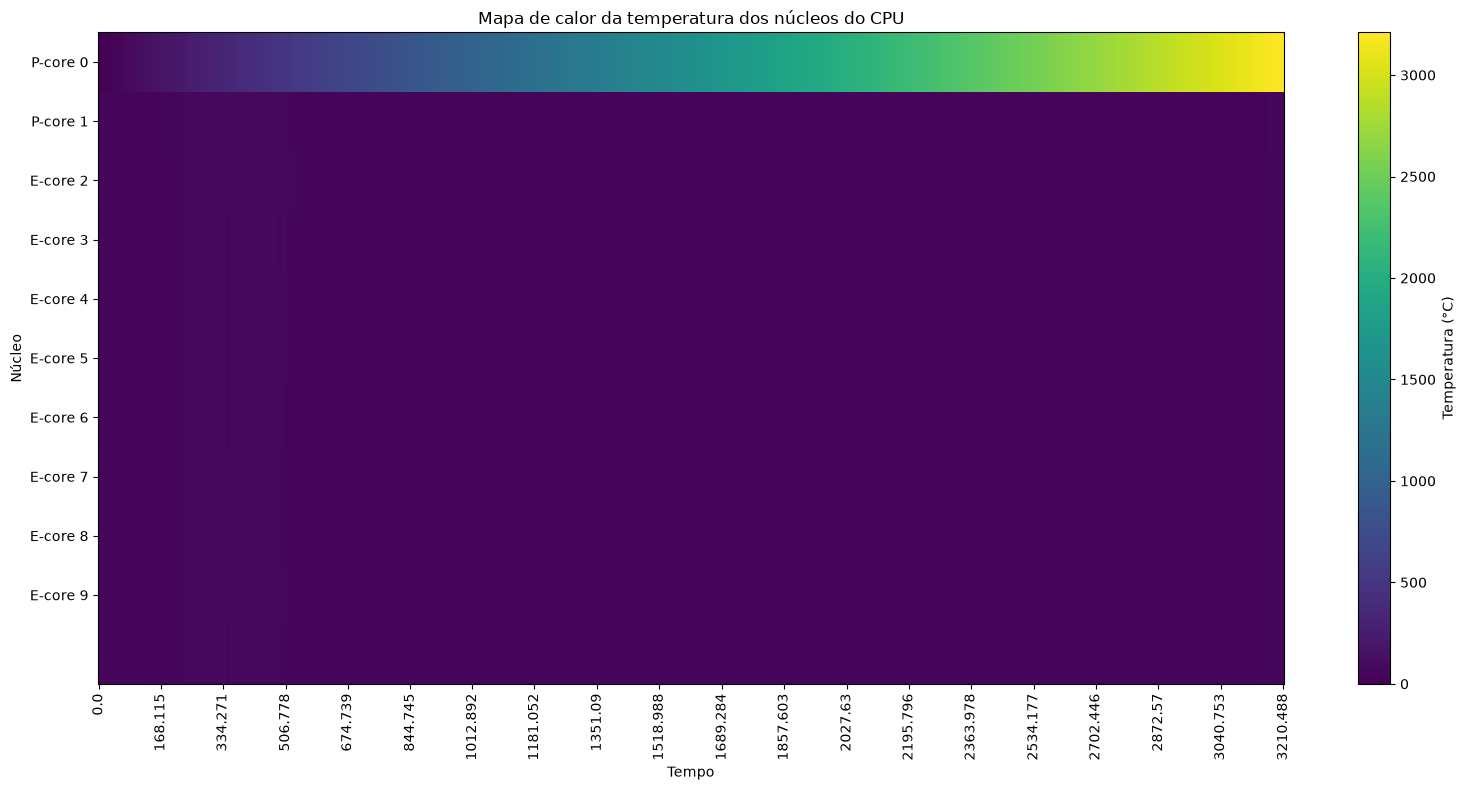

In [51]:
temp_fields = [field for field in fields if field != "Time"]

fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(
    dataset.T,
    aspect="auto",
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperatura (°C)")

# Seleciona aproximadamente 10 marcações no eixo do tempo
n_ticks = 20
indices = np.linspace(
    0,
    len(dataset) - 1,
    n_ticks,
    dtype=int
)

ax.set_xticks(indices)
ax.set_xticklabels(
    dataset["Elapsed Time [s]"].iloc[indices],
    rotation=90
)

ax.set_yticks(range(len(temp_fields)))
ax.set_yticklabels([
    temp_field.replace(" [°C]", "") for temp_field in temp_fields
])

ax.set_xlabel("Tempo")
ax.set_ylabel("Núcleo")
ax.set_title("Mapa de calor da temperatura dos núcleos do CPU")

plt.tight_layout()
plt.show()